In [1]:
import pandas as pd
import seaborn as srn
import statistics as sts 

## Importando o arquivo Tempo.CSV

AparÊncia deve constar Sol, Nublado, Chuva
Temperatura: 0~130F
Umidade: 0~100

In [2]:
dataset = pd.read_csv ('tempo.csv', sep = ';')

## Visualizar

In [3]:
dataset.head()

,Aparencia,Temperatura,Umidade,Vento,Jogar
0,sol,85,85.0,FALSO,nao
1,sol,80,90.0,VERDADEIRO,nao
2,nublado,83,86.0,FALSO,sim
3,chuva,70,NaN,FALSO,sim
4,chuva,68,80.0,FALSO,sim


## Visualizar Tamanho da amostra

In [4]:
dataset.shape

(14, 5)

## Agrupar pela Aparência

In [5]:
agrupadoAparencia = dataset.groupby(['Aparencia']).size()
agrupadoAparencia

Aparencia
chuva      5
menos      1
nublado    3
sol        5
dtype: int64

## Explorando coluna Temperatura

<Axes: xlabel='Aparencia'>

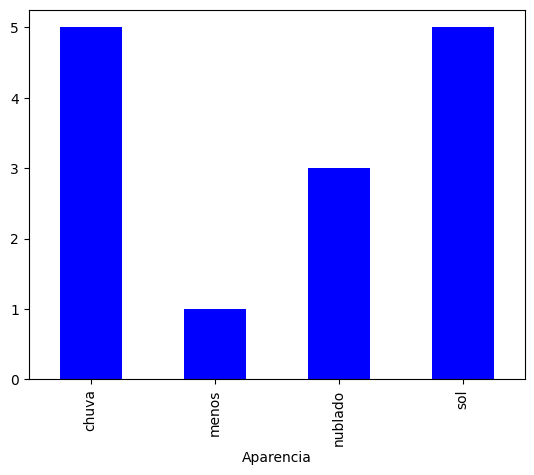

In [6]:
agrupadoAparencia.plot.bar(color = "blue")

## Explorando coluna Vento

In [7]:
agrupadoVento = dataset.groupby(['Vento']).size()
agrupadoVento

Vento
FALSO         7
VERDADEIRO    6
dtype: int64

<Axes: xlabel='Vento'>

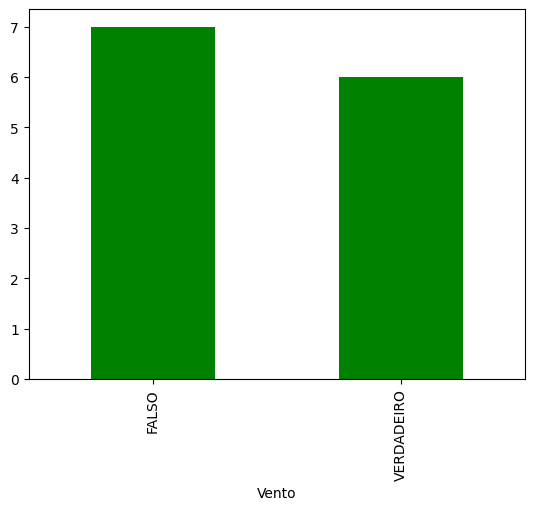

In [8]:
agrupadoVento.plot.bar(color = 'green')

## Explorando coluna Jogar

In [9]:
agrupadoJogar = dataset.groupby(['Jogar']).size()
agrupadoJogar

Jogar
nao    5
sim    9
dtype: int64

<Axes: xlabel='Vento'>

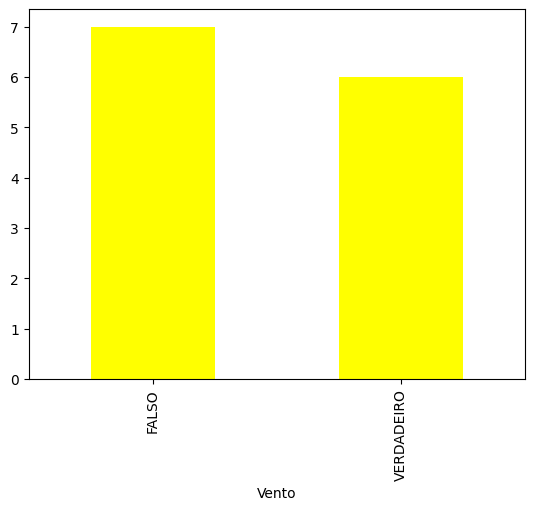

In [10]:
agrupadoVento.plot.bar(color = 'yellow')

### Explorando colunas numéricas
## Explorando coluna Temperatura

In [11]:
dataset['Temperatura'].describe()

count      14.000000
mean      155.571429
std       306.433759
min        64.000000
25%        69.250000
50%        73.500000
75%        80.750000
max      1220.000000
Name: Temperatura, dtype: float64

Text(0.5, 1.0, 'Temperatura')

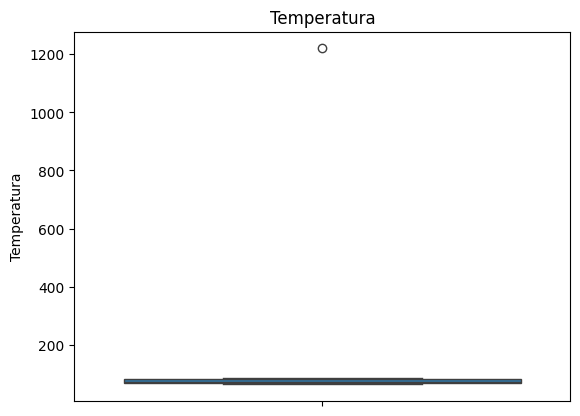

In [12]:
srn.boxplot(dataset["Temperatura"]).set_title('Temperatura')

Text(0.5, 1.0, 'Temperatura')

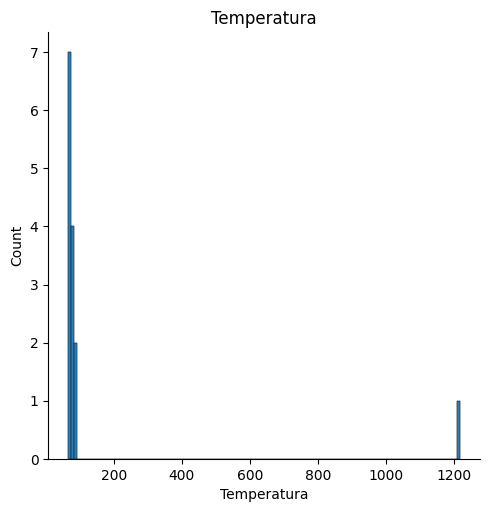

In [13]:
srn.displot(dataset['Temperatura']).set_titles('Temperatura')
srn.histplot(dataset['Temperatura']).set_title('Temperatura')

## Explorano coluna Umidade

In [14]:
dataset['Umidade'].describe()


count     13.000000
mean      89.769231
std       34.540203
min       65.000000
25%       70.000000
50%       85.000000
75%       90.000000
max      200.000000
Name: Umidade, dtype: float64

Text(0.5, 1.0, 'Umidade')

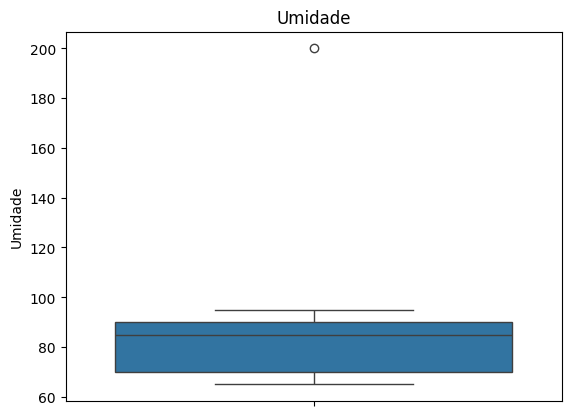

In [15]:
srn.boxplot(dataset['Umidade']).set_title('Umidade')


C:\Users\NoteDell\AppData\Local\Temp\ipykernel_7456\640715104.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  srn.distplot(dataset['Umidade']).set_title('Umidade')


Text(0.5, 1.0, 'Umidade')

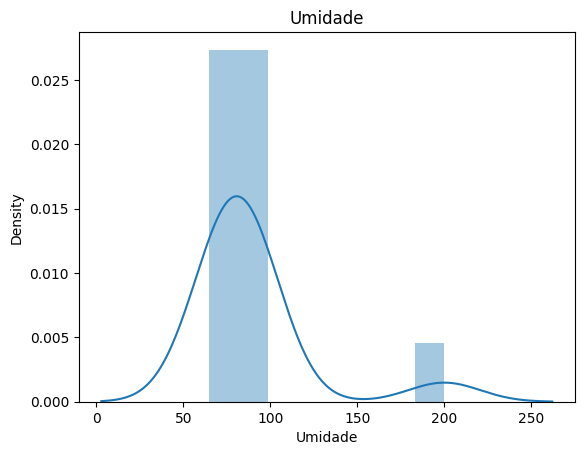

In [16]:
srn.distplot(dataset['Umidade']).set_title('Umidade')

In [17]:
dataset.isnull().sum()

Aparencia      0
Temperatura    0
Umidade        1
Vento          1
Jogar          0
dtype: int64

In [18]:
dataset.loc[dataset['Aparencia'] ==  'menos', 'Aparencia'] = "Sol"
#visualiza o resultado
agrupado = dataset.groupby(['Aparencia']).size()
agrupado

Aparencia
Sol        1
chuva      5
nublado    3
sol        5
dtype: int64

In [19]:
dataset['Temperatura'].describe()

count      14.000000
mean      155.571429
std       306.433759
min        64.000000
25%        69.250000
50%        73.500000
75%        80.750000
max      1220.000000
Name: Temperatura, dtype: float64

In [20]:
dataset.loc[(dataset['Temperatura'] < -130 ) | (dataset['Temperatura'] > 130)]

,Aparencia,Temperatura,Umidade,Vento,Jogar
7,sol,1220,95.0,FALSO,nao


In [21]:
mediana = sts.median(dataset['Temperatura'])
mediana

73.5

In [24]:
dataset.loc[(dataset['Temperatura'] < -130 ) | (dataset['Temperatura'] > 130), 'Temperatura'] = mediana

In [25]:
dataset.loc[(dataset['Temperatura'] < -130 ) | (dataset['Temperatura'] > 130)]

,Aparencia,Temperatura,Umidade,Vento,Jogar


In [26]:
agrupado = dataset.groupby(['Umidade']).size()
agrupado

Umidade
65.0     1
70.0     3
75.0     1
80.0     1
85.0     1
86.0     1
90.0     2
91.0     1
95.0     1
200.0    1
dtype: int64

In [27]:
agrupado = dataset.groupby(['Vento']).size()
agrupado

Vento
FALSO         7
VERDADEIRO    6
dtype: int64